In [1]:
from __future__ import annotations
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp
from helperfunctions import intern_constants as ic
from pathlib import Path
from helperfunctions.detection import ks_test as ks


In [2]:
ts = pd.to_datetime("2021-01-21 12:30:00")
wt = 2
fp = Path(ic.PATH_IMPUTED).glob(f"WT_ID_{wt}*")
wt_df = pd.read_csv(next(iter(fp)), parse_dates=[ic.TS_COL])

cols = ['Gear oil temperature (°C)', 'Rear bearing temperature (°C)', 'Front bearing temperature (°C)']



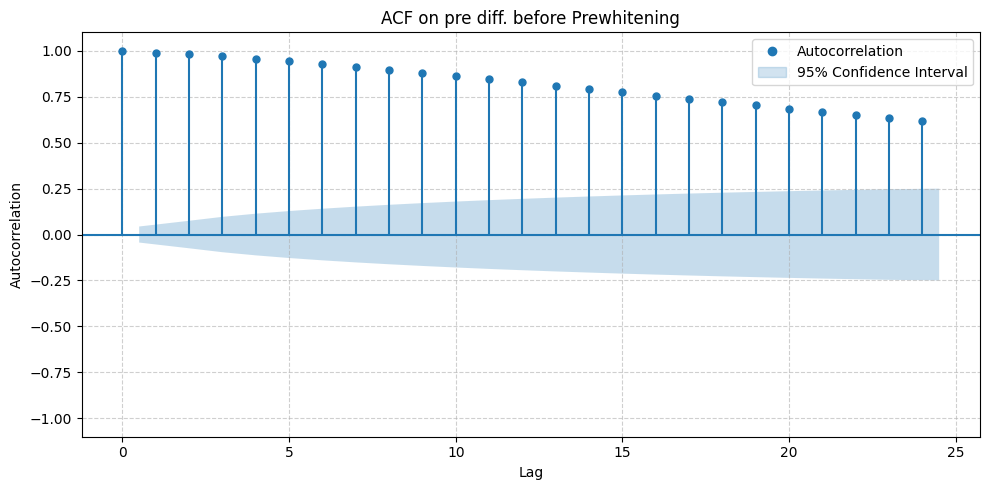

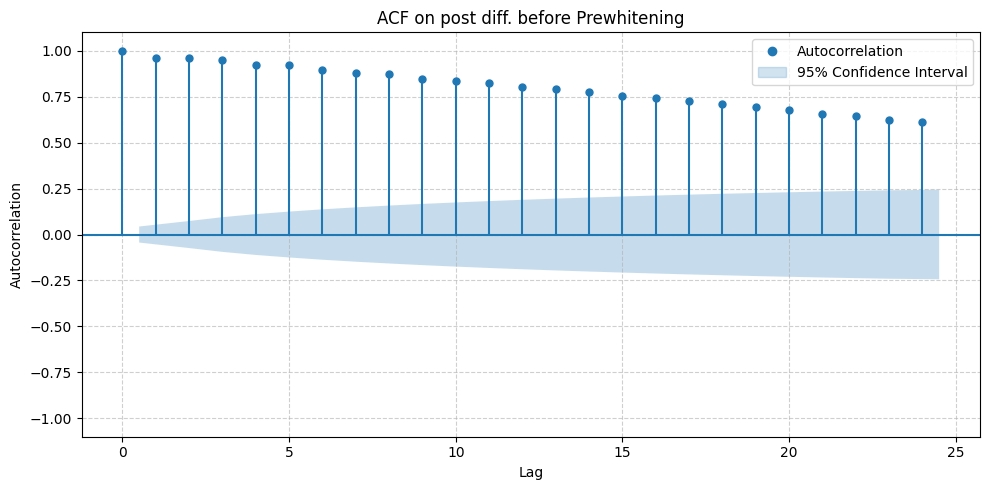

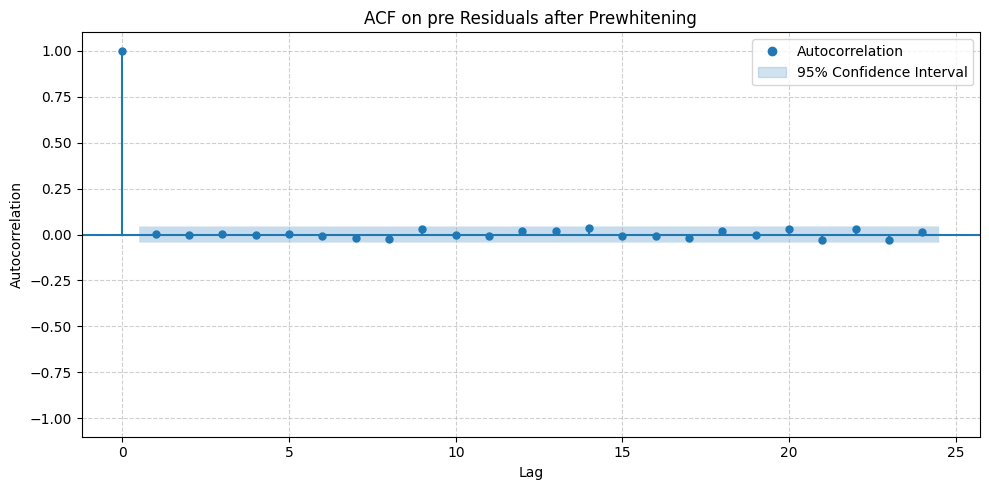

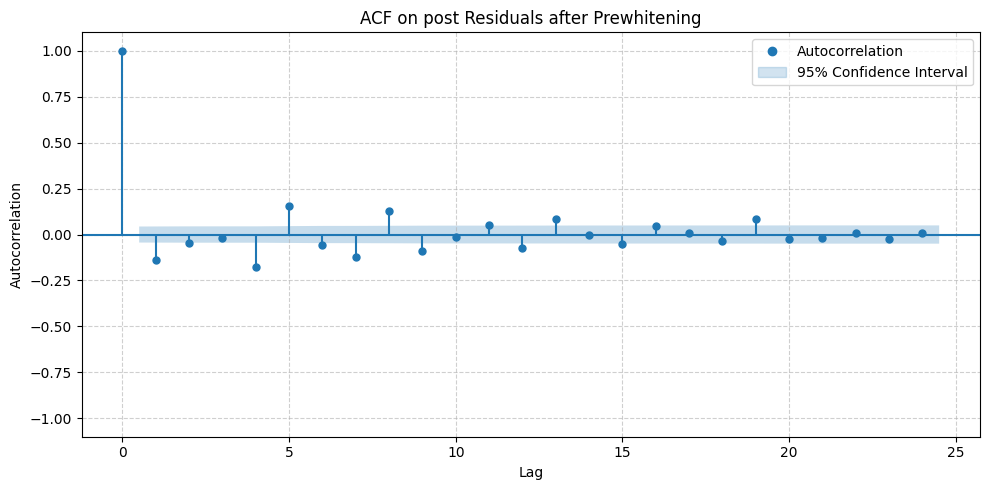

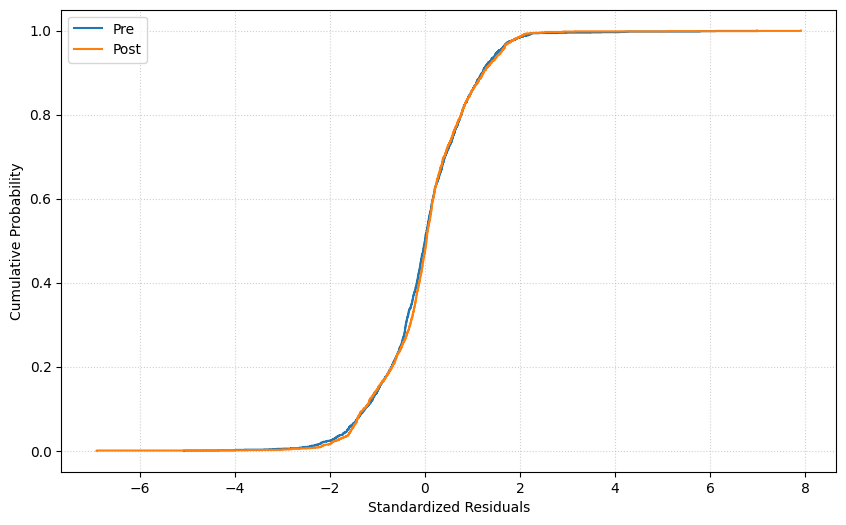

In [3]:
pipeline_results = ks.run_prewhitening_ks_pipeline(
    df=wt_df,
    col=cols[0],
    ts_det=ts,
    offset=pd.Timedelta(days=14),
    adf_alpha=0.05,
    adf_regression="c",
    adf_autolag="AIC",
    max_d = 5,
    p_max=24,
    include_const=True,
    ks_method="asymp",
    ks_alternative="two-sided",
    acf_k=24,
    plot=True,
)

In [4]:
display(pipeline_results)

{'signal': 'Gear oil temperature (°C)',
 'ts_det': Timestamp('2021-01-21 12:30:00'),
 'offset': Timedelta('14 days 00:00:00'),
 'n_pre_raw': 2016,
 'n_post_raw': 2016,
 'd': 0,
 'adf': {'x': array([56.72833341, 56.836667  , 56.8649999 , ..., 54.05999934,
         56.62666613, 55.10666669]),
  'd': 0,
  'adf_pre': ks_test.ADFResult(test_stat=-4.397187907435095, p_value=0.0003002526334302467, lag=8, n_obs=2007),
  'stationary_pre': True,
  'adf_post': ks_test.ADFResult(test_stat=-4.397187907435095, p_value=0.0003002526334302467, lag=8, n_obs=2007),
  'stationary_post': True,
  'adf_path': [ks_test.ADFResult(test_stat=-4.397187907435095, p_value=0.0003002526334302467, lag=8, n_obs=2007)],
  'stationary_path': [True]},
 'order_table':      p     n   k  n_over_k_lt_40           aic          aicc prefer
 0    8  2016  10           False   5820.866998   5820.976723    aic
 1    9  2016  11           False   5820.932244   5821.063981    aic
 2   10  2016  12           False   5821.640436   582

In [5]:
report_windows = ks.report_windows(pipeline_results)
display(report_windows)

,wt_id,signal,detection,pre start,pre end,pre samples,post start,post_end,post samples
0,2,Gear oil temperature (°C),2021-01-21 12:30:00,2021-01-07 12:30:00,2021-01-21 12:30:00,2016,2021-01-21 12:40:00,2021-02-04 12:40:00,2016


In [6]:
report_stat = ks.report_stationarity(pipeline_results)
display(report_stat)

,test,h0,decision rule,regression model,alpha,pre test_stat,pre p value,pre lag,pre samples,pre is stationary,post teststat,post p value,post lag,post samples,post is stationary,d applied to pre and post
0,ADF,unit root (non-stationary),stationary if p_value <= alpha,c,0.05,-4.397188,0.0003,8,2007,True,-4.397188,0.0003,8,2007,True,0


In [7]:
report_ar_wh = ks.report_AR_whitening(pipeline_results)
display(report_ar_wh)

,order selection,value,order p,model,model params.,intercept:
0,aic,5820.866998,8,AR(p),"[0.6584564772729206, 0.4256045383080813, 0.171...",0.84299


In [8]:
report_std = ks.report_standardization(pipeline_results)
display(report_std)

,sigma_pre (for pre and post),sigma_post
0,1.021028,0.991662


In [9]:
report_whn = ks.report_white_noise_before_ks_test(pipeline_results)
display(report_whn)

,test method,pre is white noise,pre test stat.,pre p value,post is white noise,post test stat.,post p value,alpha,lags
0,Ljung-Box-Test,True,17.13848,0.842696,False,301.162007,9.784079e-50,0.05,24


In [ ]:
report_ks = ks.report_ks(pipeline_results)
display(report_ks)

,method,alternative,D,D_crit,reject h0,p_value,alpha,n_pre,n_post,cliffs_delta
0,asymp,two-sided,0.043483,0.042879,True,0.043247,0.05,2008,2016,0.017029


: 